# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 23 - 1er bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del jueves 9 de abril (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/PWKB3VxQPCFqEo5AA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co23.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

### Importación de librerías y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Carga del dataset Adult Census Income
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(url, names=columns, sep=r',\s*', engine='python', na_values='?')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Registros: {df.shape[0]}, Variables: {df.shape[1]}")
df.head()

Dimensiones del dataset: (32561, 15)
Registros: 32561, Variables: 15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Inspección general del dataset

In [2]:
# Tipos de datos e información general
print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas")
print("=" * 60)
df.describe().round(2)

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


VALORES NULOS POR VARIABLE
                Nulos  Porcentaje (%)
workclass        1836            5.64
occupation       1843            5.66
native-country    583            1.79

Total de filas con al menos un nulo: 2399 (7.37%)


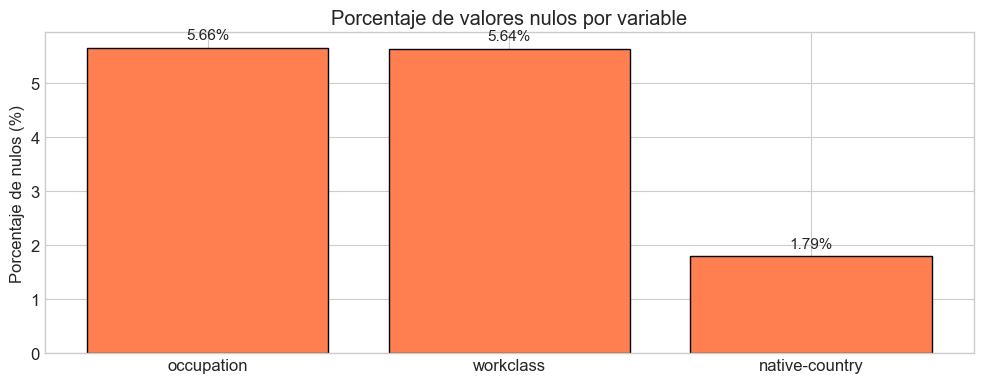

In [3]:
# Análisis de valores nulos
print("=" * 60)
print("VALORES NULOS POR VARIABLE")
print("=" * 60)
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, 'Porcentaje (%)': null_pct})
null_df = null_df[null_df['Nulos'] > 0]

if null_df.empty:
    print("No se encontraron valores nulos en el dataset.")
else:
    print(null_df)
    print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).sum()/len(df)*100:.2f}%)")

    # Gráfico de valores nulos
    fig, ax = plt.subplots(figsize=(10, 4))
    null_pct_nonzero = null_pct[null_pct > 0].sort_values(ascending=False)
    bars = ax.bar(null_pct_nonzero.index, null_pct_nonzero.values, color='coral', edgecolor='black')
    ax.set_ylabel('Porcentaje de nulos (%)')
    ax.set_title('Porcentaje de valores nulos por variable')
    for bar, val in zip(bars, null_pct_nonzero.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val}%',
                ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()

### Análisis de cardinalidad de variables categóricas

Analizamos los valores únicos de cada variable categórica para determinar su nivel de cardinalidad. Según la consigna, variables con 10 o más valores únicos se consideran de **alta cardinalidad**.

In [4]:
# Identificar variables categóricas y numéricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Variables numéricas ({len(num_cols)}): {num_cols}")

# Tabla de cardinalidad
print("\n" + "=" * 70)
print("CARDINALIDAD DE VARIABLES CATEGÓRICAS")
print("=" * 70)
cardinality = []
for col in cat_cols:
    n_unique = df[col].nunique()
    level = "ALTA (≥10)" if n_unique >= 10 else "BAJA (<10)"
    cardinality.append({'Variable': col, 'Valores únicos': n_unique, 'Cardinalidad': level})

card_df = pd.DataFrame(cardinality).sort_values('Valores únicos', ascending=False)
print(card_df.to_string(index=False))

# Mostrar valores únicos de cada variable categórica
print("\n" + "=" * 70)
print("VALORES ÚNICOS POR VARIABLE CATEGÓRICA")
print("=" * 70)
for col in cat_cols:
    print(f"\n--- {col} ({df[col].nunique()} valores únicos) ---")
    print(df[col].value_counts())

Variables categóricas (9): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Variables numéricas (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

CARDINALIDAD DE VARIABLES CATEGÓRICAS
      Variable  Valores únicos Cardinalidad
native-country              41   ALTA (≥10)
     education              16   ALTA (≥10)
    occupation              14   ALTA (≥10)
     workclass               8   BAJA (<10)
marital-status               7   BAJA (<10)
  relationship               6   BAJA (<10)
          race               5   BAJA (<10)
           sex               2   BAJA (<10)
        income               2   BAJA (<10)

VALORES ÚNICOS POR VARIABLE CATEGÓRICA

--- workclass (8 valores únicos) ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay           

### Distribución de la variable target

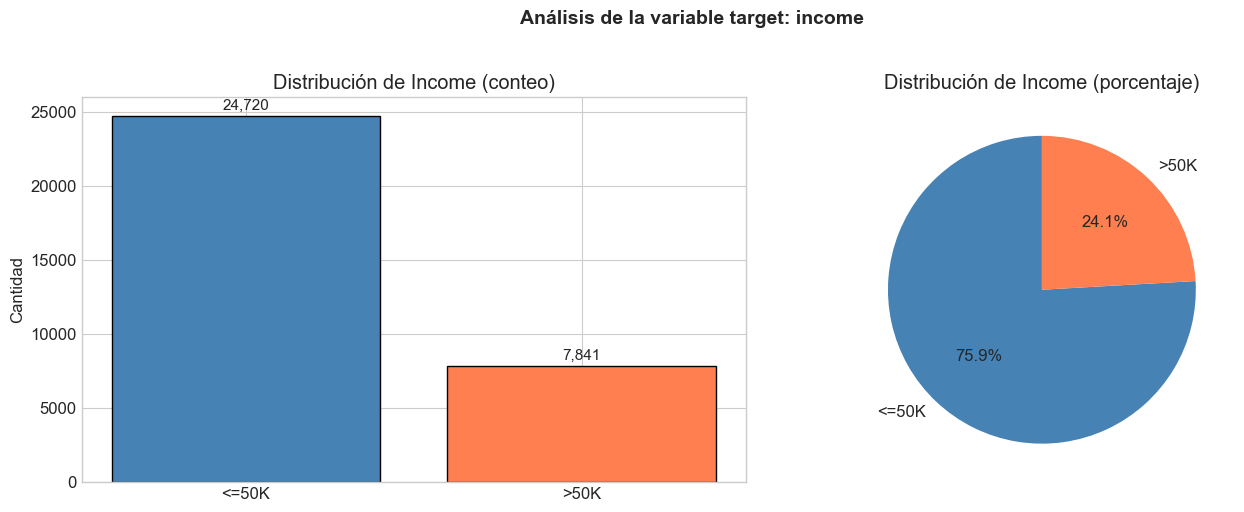


Balance de clases:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Ratio mayoría/minoría: 3.15:1


In [5]:
# Distribución del target (income)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo absoluto
income_counts = df['income'].value_counts()
bars = axes[0].bar(income_counts.index, income_counts.values, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Distribución de Income (conteo)')
axes[0].set_ylabel('Cantidad')
for bar, val in zip(bars, income_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)

# Porcentaje
income_pct = (income_counts / len(df) * 100).round(1)
wedges, texts, autotexts = axes[1].pie(income_pct.values, labels=income_pct.index,
                                        autopct='%1.1f%%', colors=['steelblue', 'coral'],
                                        startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Distribución de Income (porcentaje)')

plt.suptitle('Análisis de la variable target: income', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBalance de clases:\n{income_counts}")
print(f"\nRatio mayoría/minoría: {income_counts.max()/income_counts.min():.2f}:1")

### Distribución de variables numéricas

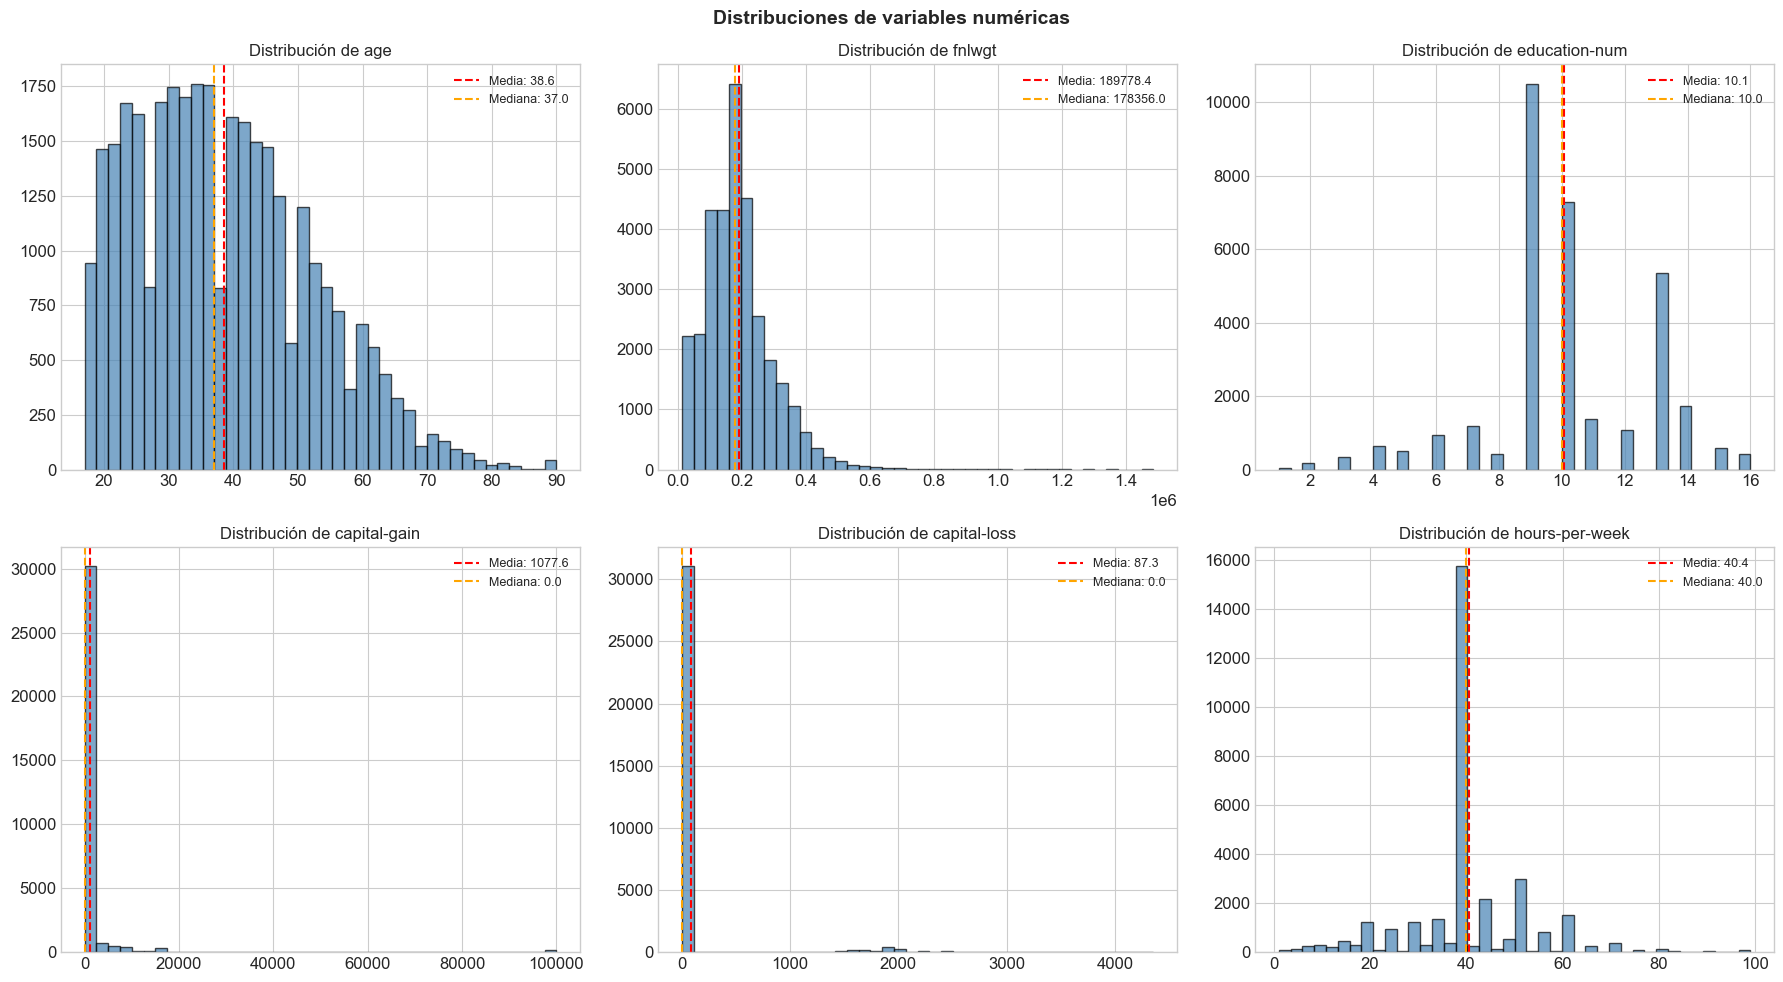

In [6]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(f'Distribución de {col}', fontsize=12)
    ax.legend(fontsize=9)

# Ocultar ejes sobrantes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Distribución de variables categóricas

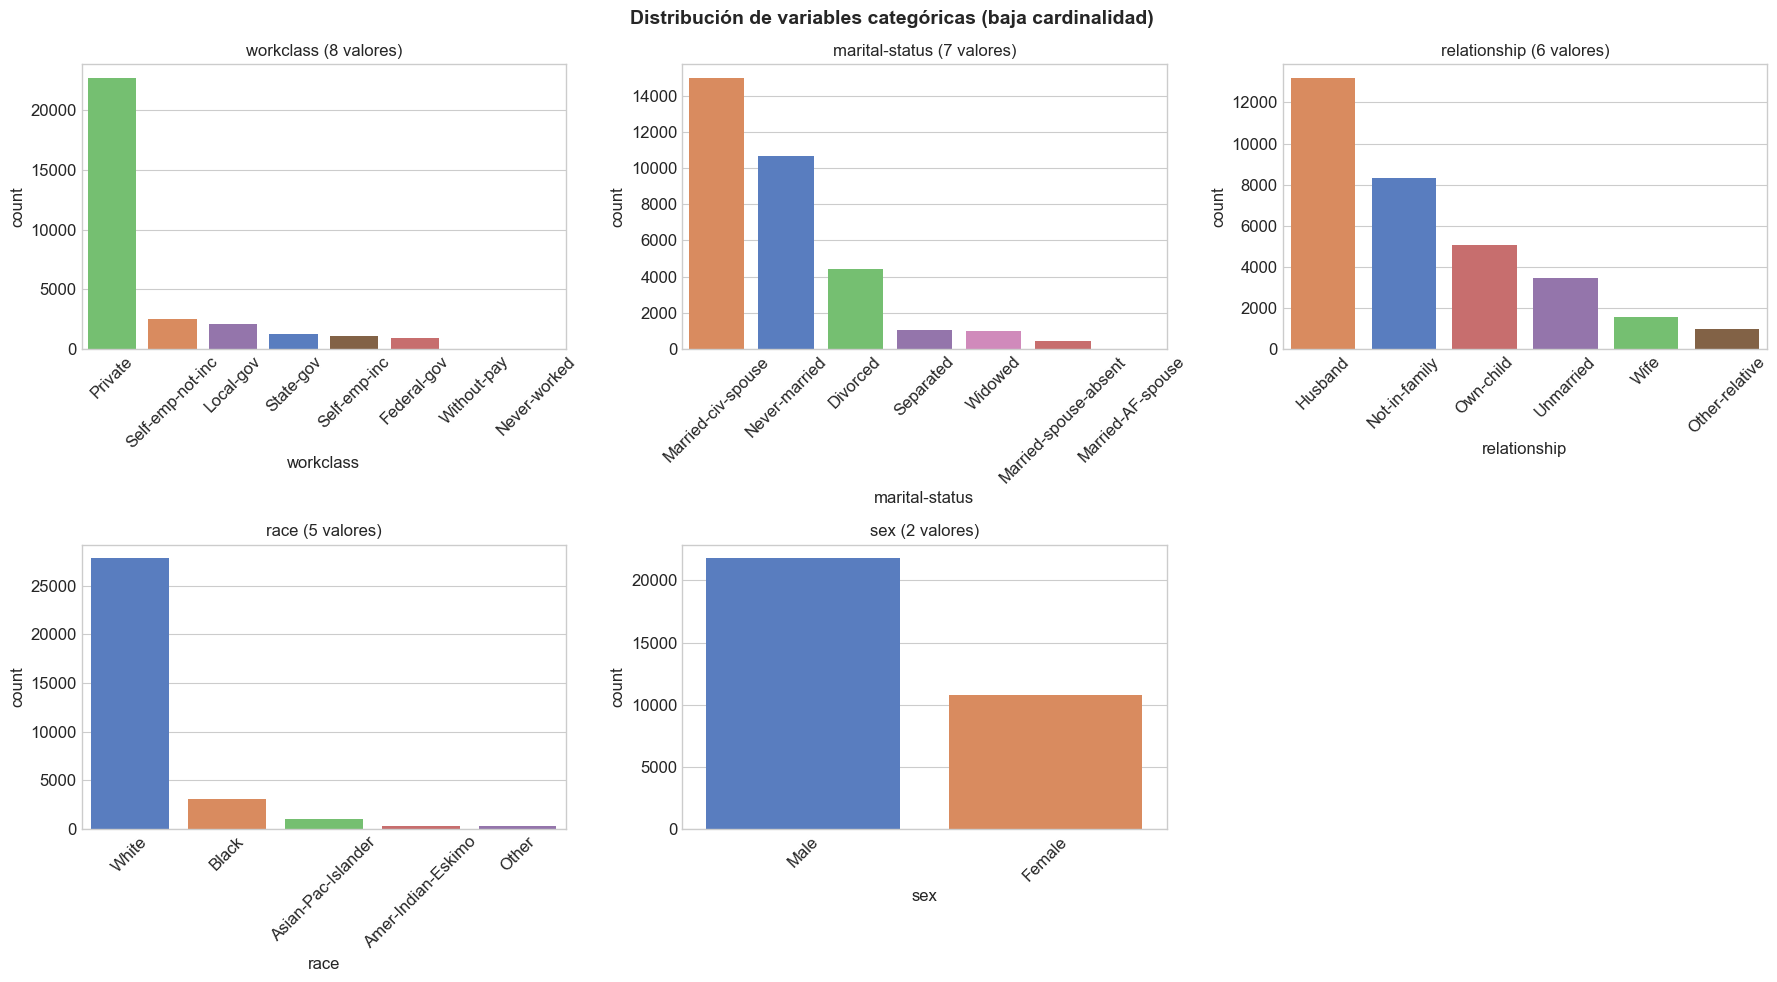

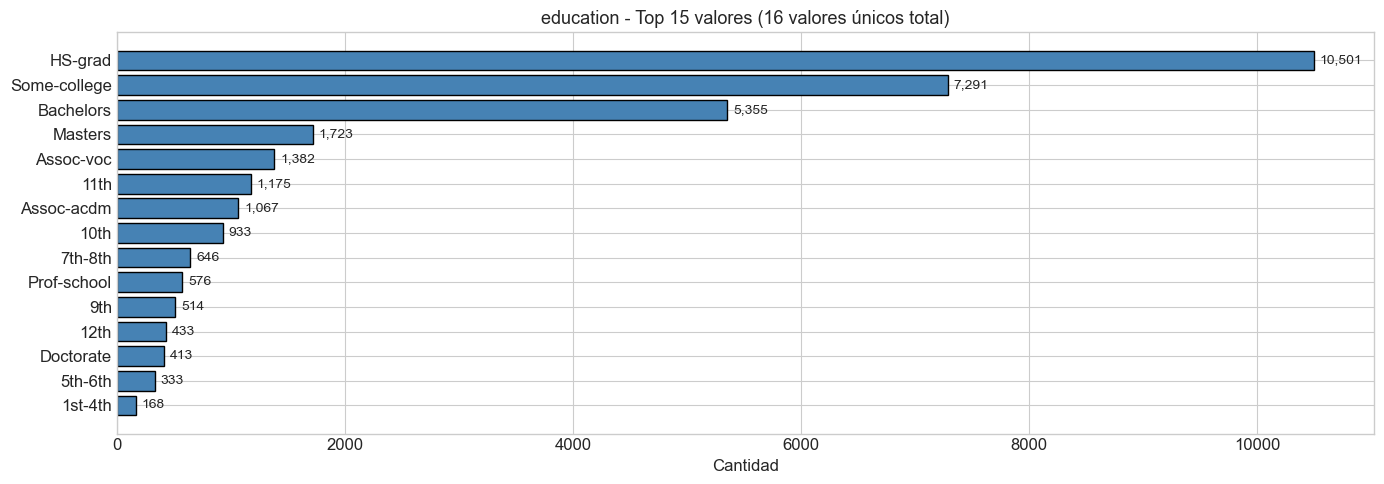

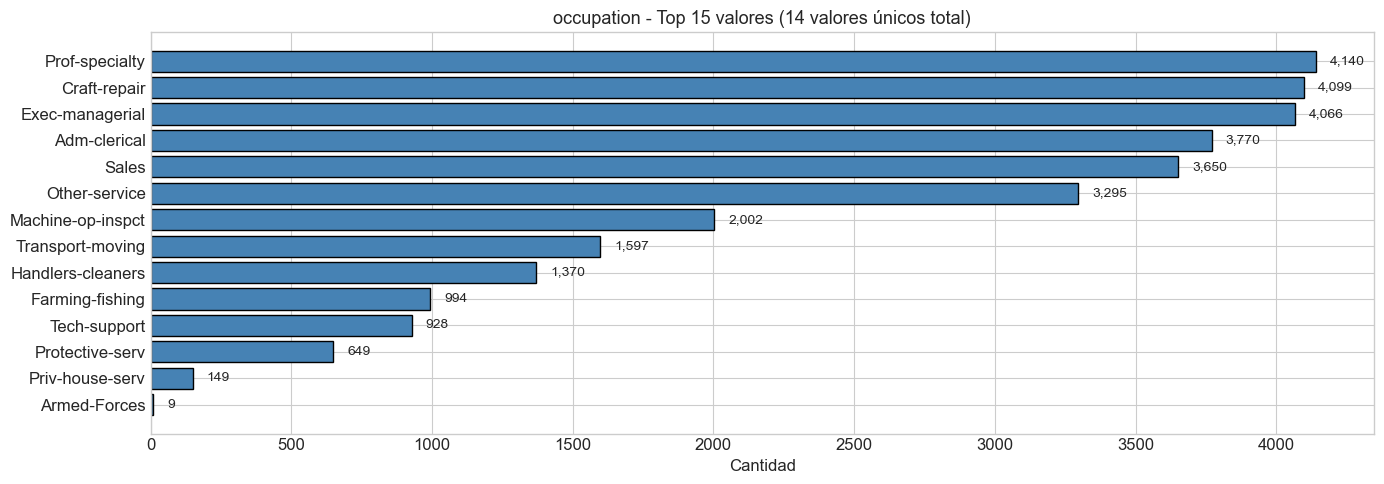

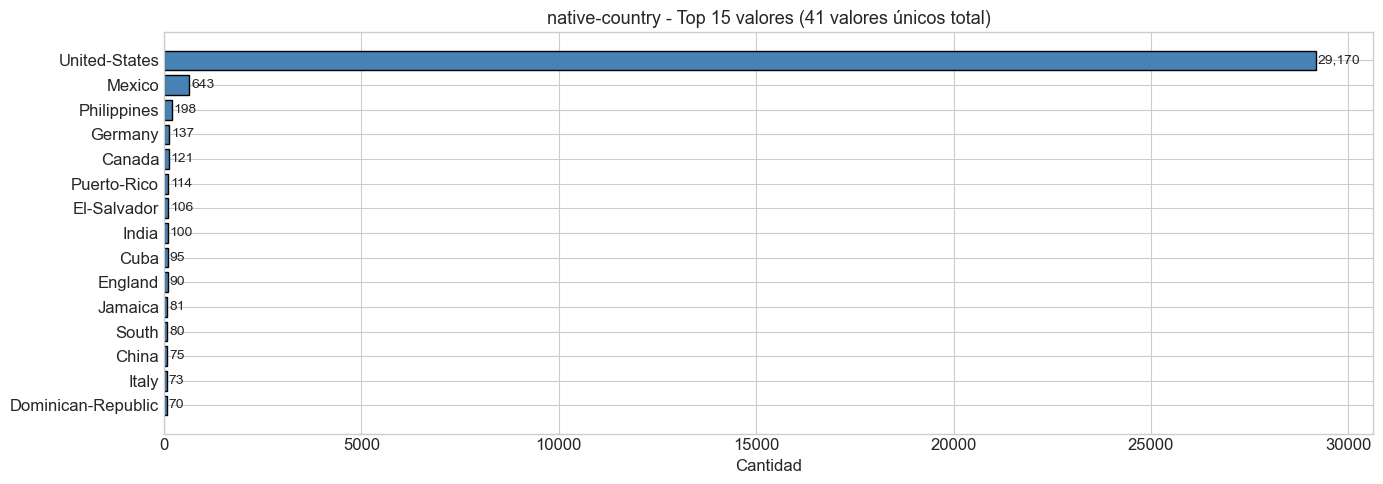

In [7]:
# Distribución de variables categóricas (excluyendo target)
cat_cols_no_target = [c for c in cat_cols if c != 'income']

# Variables de baja cardinalidad (< 10 valores únicos)
low_card = [c for c in cat_cols_no_target if df[c].nunique() < 10]
# Variables de alta cardinalidad (>= 10 valores únicos)
high_card = [c for c in cat_cols_no_target if df[c].nunique() >= 10]

# Gráficos para variables de baja cardinalidad
n_low = len(low_card)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(low_card):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order, hue=col, palette='muted', legend=False)
    ax.set_title(f'{col} ({df[col].nunique()} valores)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

for j in range(n_low, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas (baja cardinalidad)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gráficos para variables de alta cardinalidad (top 15)
for col in high_card:
    fig, ax = plt.subplots(figsize=(14, 5))
    top_vals = df[col].value_counts().head(15)
    bars = ax.barh(top_vals.index[::-1], top_vals.values[::-1], color='steelblue', edgecolor='black')
    ax.set_title(f'{col} - Top 15 valores ({df[col].nunique()} valores únicos total)', fontsize=13)
    ax.set_xlabel('Cantidad')
    for bar, val in zip(bars, top_vals.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{val:,}',
                ha='left', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

### Relación entre variables categóricas y el target (income)

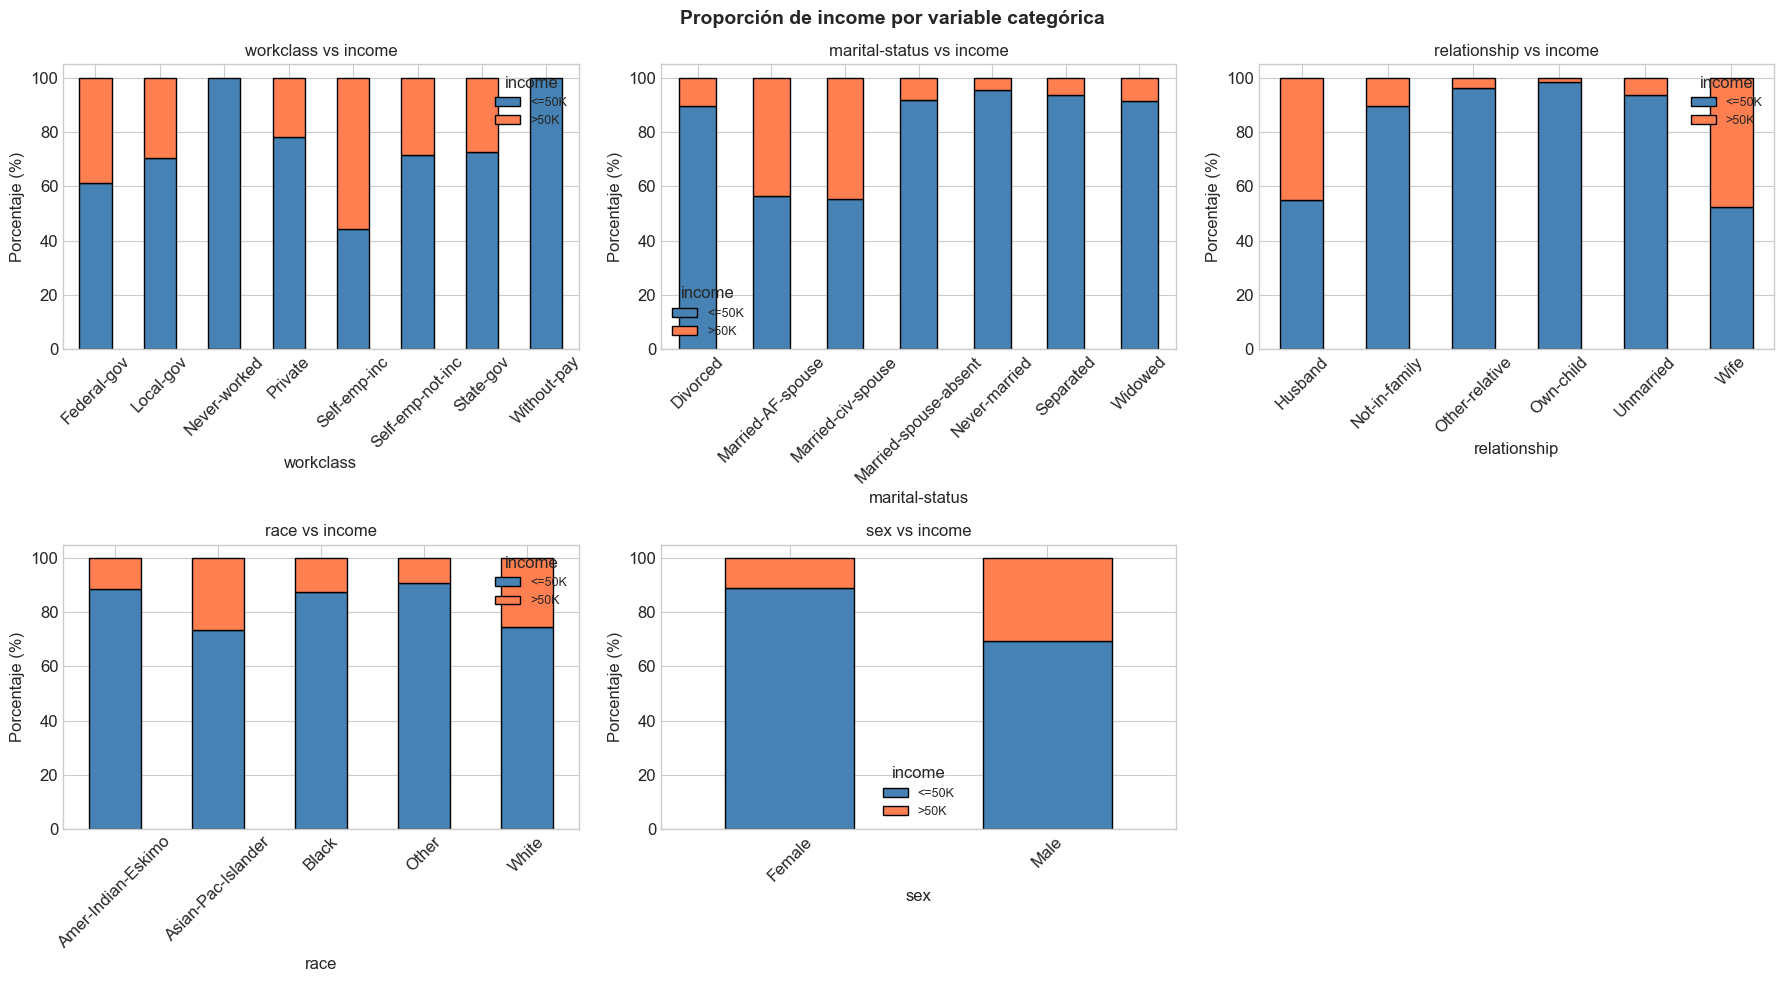

In [8]:
# Relación entre variables categóricas de baja cardinalidad y el target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(low_card):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['income'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{col} vs income', fontsize=12)
    ax.set_ylabel('Porcentaje (%)')
    ax.legend(title='income', fontsize=9)
    ax.tick_params(axis='x', rotation=45)

for j in range(len(low_card), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Proporción de income por variable categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Relación entre variables numéricas y el target

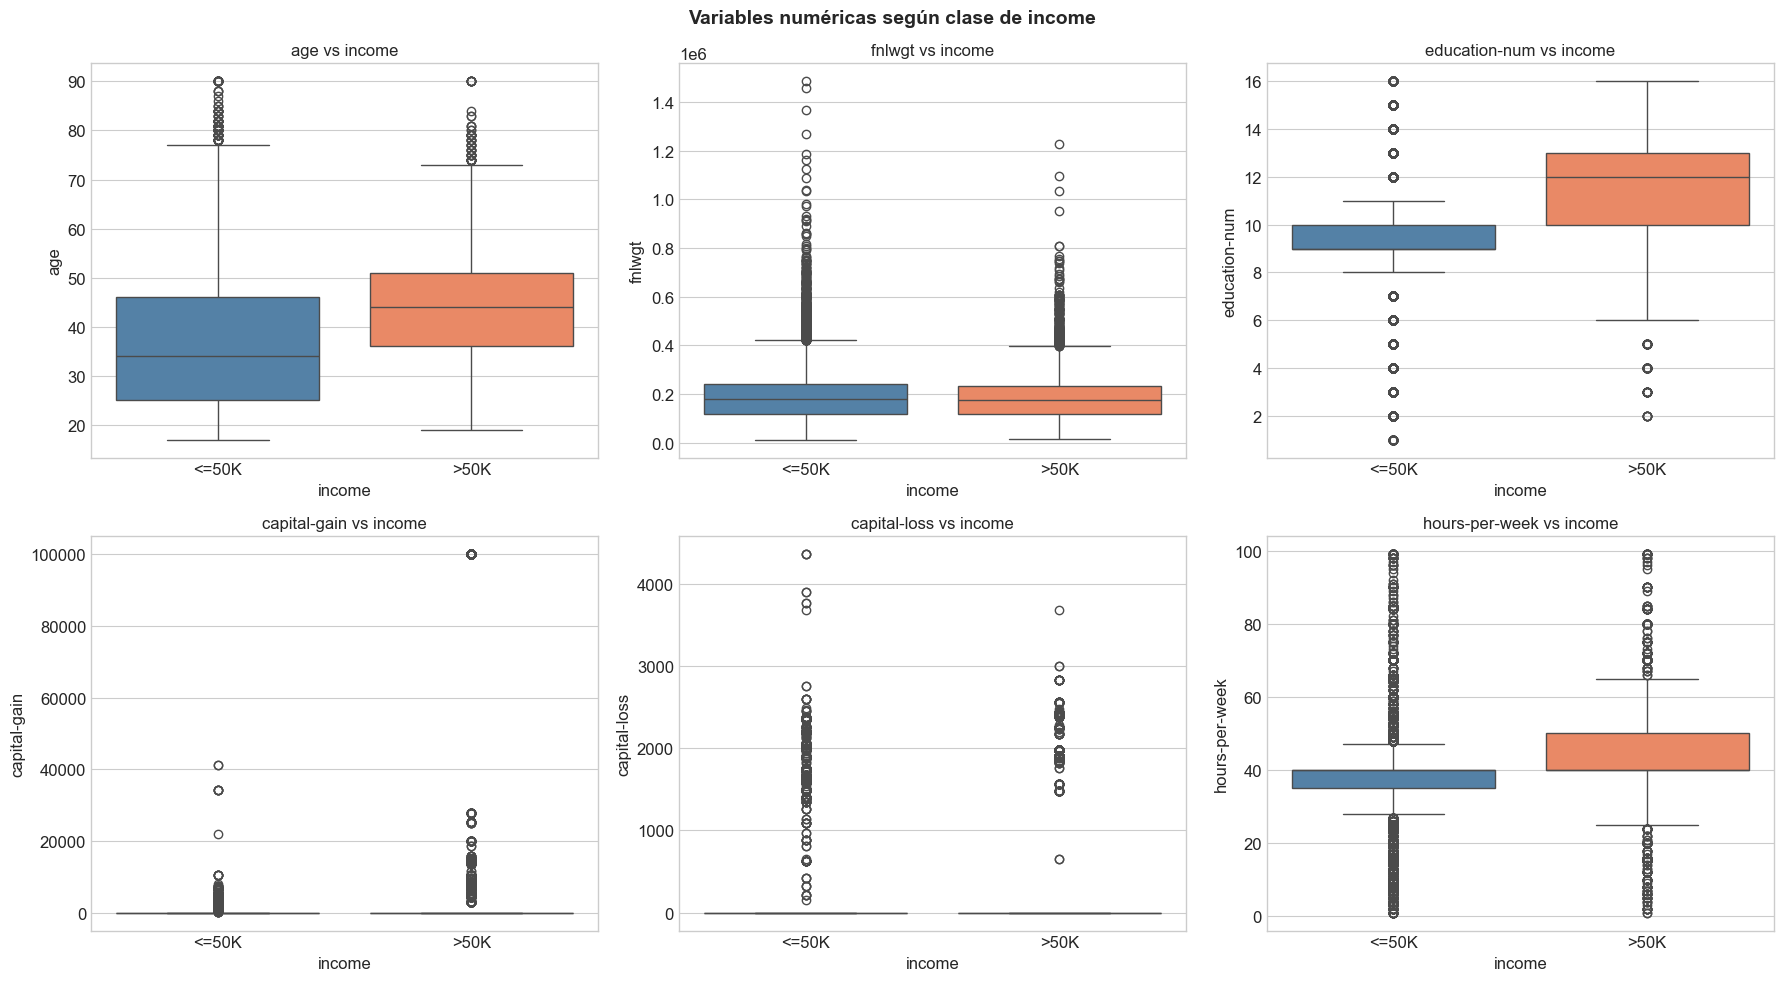

In [9]:
# Box plots: variables numéricas vs income
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='income', y=col, ax=ax, palette=['steelblue', 'coral'], hue='income', legend=False)
    ax.set_title(f'{col} vs income', fontsize=12)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas según clase de income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de correlación

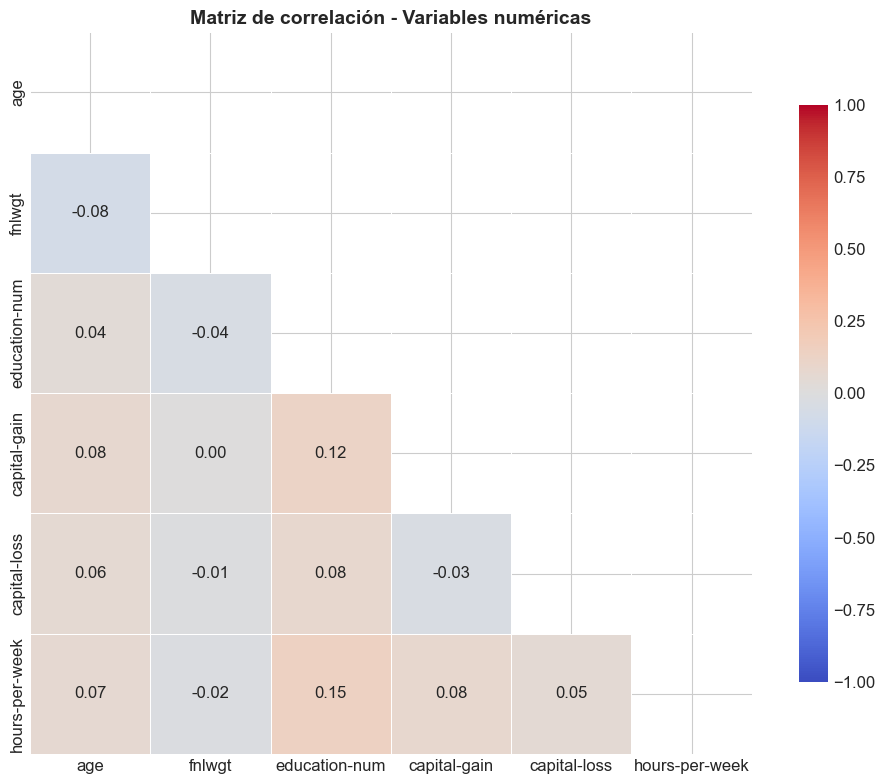

In [10]:
# Mapa de calor de correlaciones (solo variables numéricas)
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación - Variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Decisiones de transformación por variable

A partir del análisis exploratorio, se definen las transformaciones para cada variable. Las decisiones se basan en la cardinalidad, el contexto semántico y la presencia o ausencia de orden natural.

| Variable | Tipo | Cardinalidad | Transformación propuesta | Justificación |
|---|---|---|---|---|
| **age** | Numérica | Continua | Normalización (StandardScaler) | Variable continua, se escala para estabilizar el entrenamiento |
| **workclass** | Categórica | Baja (≈9) | One-hot encoding / Embedding | Sin orden natural, baja cardinalidad → OHE viable. También se probará embedding para comparar |
| **fnlwgt** | Numérica | Continua | Evaluar eliminación o normalización | Peso muestral del censo, no es una feature predictiva directa |
| **education** | Categórica | Media (16) | Embedding | Tiene orden natural parcial pero alta cardinalidad para OHE. Se usa `education-num` como alternativa ordinal |
| **education-num** | Numérica | Ordinal (16) | Normalización | Versión numérica de education con orden natural. Se puede usar en lugar de education |
| **marital-status** | Categórica | Baja (7) | One-hot encoding / Embedding | Sin orden claro, baja cardinalidad |
| **occupation** | Categórica | Media-Alta (≈15) | Embedding | Sin orden natural, cardinalidad media-alta → ideal para embedding |
| **relationship** | Categórica | Baja (6) | One-hot encoding / Embedding | Sin orden natural, baja cardinalidad |
| **race** | Categórica | Baja (5) | One-hot encoding / Embedding | Sin orden natural, muy baja cardinalidad |
| **sex** | Categórica | Binaria (2) | Label encoding (0/1) | Solo 2 categorías, binaria natural |
| **capital-gain** | Numérica | Continua | Normalización | Muy sesgada (mayoría en 0), se escala |
| **capital-loss** | Numérica | Continua | Normalización | Mismo patrón que capital-gain |
| **hours-per-week** | Numérica | Continua | Normalización | Variable continua estándar |
| **native-country** | Categórica | Alta (42) | Embedding | Alta cardinalidad, sin orden → embedding es la opción óptima |
| **income** | Target | Binaria | Label encoding (≤50K→0, >50K→1) | Variable target binaria |

> **Nota:** Estas decisiones se ajustarán tras ejecutar las celdas y observar los resultados del EDA. Las variables con alta cardinalidad (`native-country`, `occupation`, `education`) serán tratadas con **embeddings** en el modelo b), y con **one-hot encoding** en el modelo c), tal como pide la consigna.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, mismas neuronas, mismas funciones de activación y la misma probabilidad de dropout.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos.
- Redactar sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.